# 13.1 Untargeted feature detection using MassCube

In [1]:
import os
from masscube.raw_data_utils import read_raw_file_to_obj
from masscube.params import Params, find_ms_info
from masscube.annotation import annotate_features
from masscube.feature_grouping import group_features_single_file

### User-defined Parameters 

In [2]:
file_name = 'swath_dia_covid/data/Covid_Cov_18_MS.mzML'    # Input mass spectrometry data file (mzML format)
ms2_library_path='swath_dia_covid/MassCube_DB_2025-06-25.pkl' # Optional MS2 spectral library (Pickle format)
segment_feature=True                                              # Whether to segment detected features into peak fragments
evaluate_peak_shape=True                                          # Whether to compute peak shape quality scores
annotate_ms2=False                                                # Whether to perform MS2-based annotation
group_features=True                                               # Whether to cluster detected features
output_dir='swath_dia_covid/'                                    # Output directory for results

### Step 1： data reading, parsing, and parameter preparation

In [3]:
params = Params()
ms_type, ion_mode, _ = find_ms_info(file_name)              # Automatically detect MS type and ion mode
params.set_default(ms_type, ion_mode)

d = read_raw_file_to_obj(file_name, params=params)          # Parse mzML file into an internal data object
d.params.ms2_library_path = ms2_library_path
d.params.bpc_dir = 'swath_dia_covid/'
d.params.plot_bpc = True

### Quality check

In [4]:
# Quality check: check if the MS1 data is valid (no MS1 data found when intensity tolerance is too high)
if len(d.ms1_idx) == 0:
  print("No valid MS1 data were found in: " + file_name + ". Please check the file and MS1 intensity tolerance.")

# Quality check: check if the file is centroided
if not d.params.is_centroid:
  print("File: " + file_name + " is not centroided and skipped.")

### Step 2. feature detection and segmentation

In [5]:
d.detect_features()                            # Perform untargeted feature detection (MS1-based)
if segment_feature:
  d.segment_features()                         # Segment complex peaks into subcomponents (optional)

### Step 3. feature evaluation

In [6]:
if evaluate_peak_shape:
  d.summarize_features(cal_g_score=True, cal_a_score=True)       # Compute G-score (Gaussian fit) and A-score (asymmetry)
else:
  d.summarize_features(cal_g_score=False, cal_a_score=False)

### Step 4. MS2 annotation

In [7]:
if annotate_ms2:
  if ms2_library_path is None:
    ms2_library_path = d.params.ms2_library_path
  if ms2_library_path is not None:
    annotate_features(d=d, sim_tol=d.params.ms2_sim_tol, fuzzy_search=True, ms2_library_path=ms2_library_path)

### Step 5. feature grouping

In [8]:
if group_features:
  group_features_single_file(d)               # Group similar features together

100%|████████████████████████████████████████████████████████████████████████████| 9348/9348 [00:09<00:00, 1030.10it/s]


### Step 6. Visualization and output

In [9]:
if d.params.plot_bpc and d.params.bpc_dir is not None:
  d.plot_bpc(output_dir=os.path.join(d.params.bpc_dir, d.params.file_name + "_bpc.png"))

if output_dir is not None:
  d.output_single_file(os.path.join(output_dir, d.params.file_name + ".txt"))                                       # Export feature table

# 13.2 Univariate analysis

### T-test

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.manifold import TSNE

In [2]:
data = pd.read_csv("metabolite_data.csv")

group_info = pd.read_csv("sample_metadata.csv")
group_info = group_info.set_index("PatientID")

none_samples = group_info[group_info["LiverFatClass"] == 'No'].index
severe_samples = group_info[group_info["LiverFatClass"] == "Severe"].index


results = []

for metabolite in data.index:
    vals_none = pd.to_numeric(data.loc[metabolite, none_samples], errors='coerce').dropna().astype(float)
    vals_severe = pd.to_numeric(data.loc[metabolite, severe_samples], errors='coerce').dropna().astype(float)

    if len(vals_none) > 1 and len(vals_severe) > 1:
        stat, pval = ttest_ind(vals_none, vals_severe, equal_var=False)
        results.append([metabolite, stat, pval, vals_none.mean(), vals_severe.mean()])
    else:
        results.append([metabolite, None, None, None, None])

df_result = pd.DataFrame(results, columns=["Metabolite", "t_statistic", "p_value", "mean_None", "mean_Severe"])
df_result["FDR"] = multipletests(df_result["p_value"], method="fdr_bh")[1]

print(df_result.head())

   Metabolite  t_statistic   p_value  mean_None  mean_Severe       FDR
0           0    -0.696693  0.497568  -0.333457     0.001009  0.818655
1           1    -0.876715  0.393980  -0.288703     0.036281  0.796268
2           2    -0.426537  0.676665  -0.145527     0.051423  0.898836
3           3     0.755655  0.458691   0.305843     0.025273  0.814059
4           4    -0.508637  0.616600  -0.152193     0.038845  0.867376


### Analysis of variance (ANOVA; F-test)

In [3]:
metabolite_df = pd.read_csv("metabolite_data.csv")
metadata_df = pd.read_csv("sample_metadata.csv") 
sample_to_group = metadata_df.set_index("PatientID")["LiverFatClass"]
grouped_samples = metadata_df.groupby("LiverFatClass")["PatientID"].apply(list)

results = []
for metabolite, row in metabolite_df.iterrows():
    group_values = []
    for group in grouped_samples.index:
        samples_in_group = grouped_samples[group]
        values = row[samples_in_group].dropna().values
        if len(values) > 1:
            group_values.append(values)
    if len(group_values) >= 2:
        f_stat, p_value = f_oneway(*group_values)
        results.append({"Metabolite": metabolite, "F_statistic": f_stat, "p_value": p_value})
    else:
        results.append({"Metabolite": metabolite, "F_statistic": None, "p_value": None})

anova_results = pd.DataFrame(results)
anova_results.to_csv("anova_results.csv", index=False)

print(anova_results.head())

   Metabolite  F_statistic   p_value
0           0     0.707228  0.552138
1           1     1.221046  0.311573
2           2     0.106979  0.955639
3           3     0.859243  0.468275
4           4     0.591247  0.623568


# 13.3 Multivariate Analysis

### Principal Component Analysis (PCA)

--- Running PCA on All Samples ---


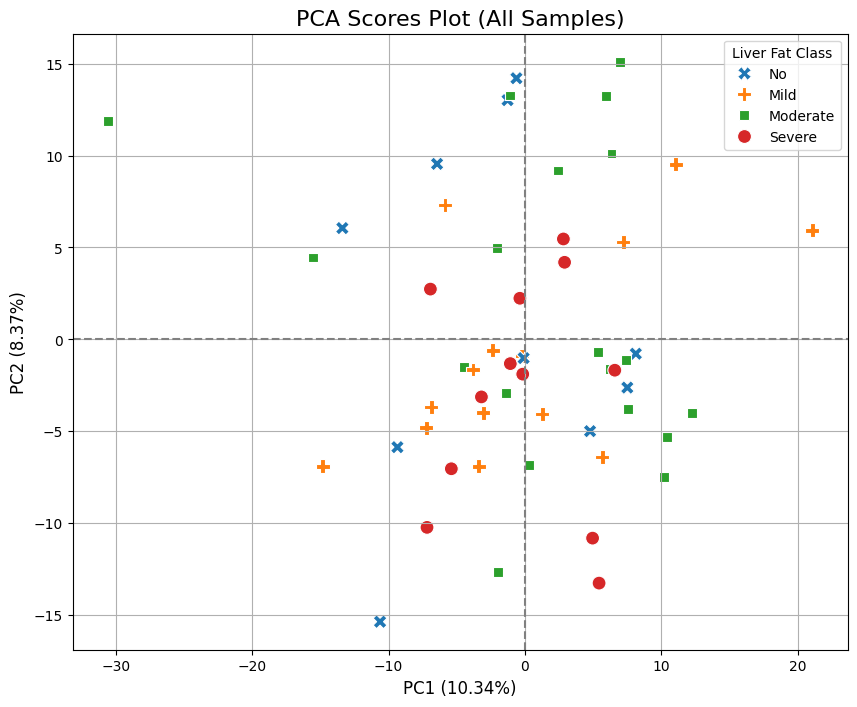

In [4]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

print("--- Running PCA on All Samples ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_full, s=100, style=y_full,
                hue_order=['No', 'Mild', 'Moderate', 'Severe']) 
plt.title('PCA Scores Plot (All Samples)', fontsize=16)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.legend(title='Liver Fat Class')
plt.grid(True)
plt.show()

### Partial Least Square Discriminant Analysis (PLS-DA)


--- Running PLS-DA ---


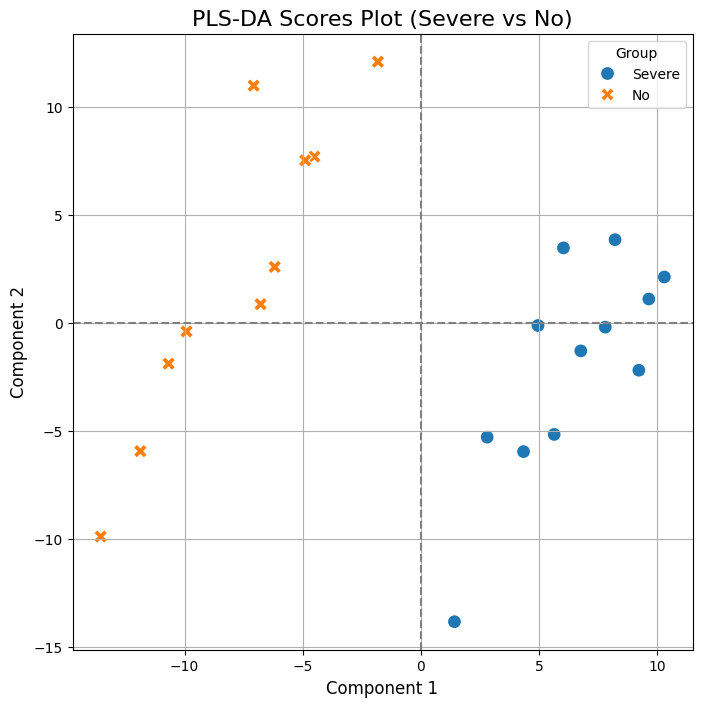

In [5]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

group1 = 'Severe'
group2 = 'No'

comparison_mask = y_full.isin([group1, group2])
X_subset = X_full[comparison_mask]
y_subset = y_full[comparison_mask]
y_subset_numeric = (y_subset == group1).astype(int)

print("\n--- Running PLS-DA ---")
plsda = PLSRegression(n_components=2)
plsda.fit(X_subset, y_subset_numeric)
X_plsda = plsda.transform(X_subset) 

plt.figure(figsize=(8, 8))
sns.scatterplot(x=X_plsda[:, 0], y=X_plsda[:, 1], hue=y_subset, s=100, style=y_subset)
plt.title(f'PLS-DA Scores Plot ({group1} vs {group2})', fontsize=16)
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.legend(title='Group')
plt.grid(True)
plt.show()

### Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA)

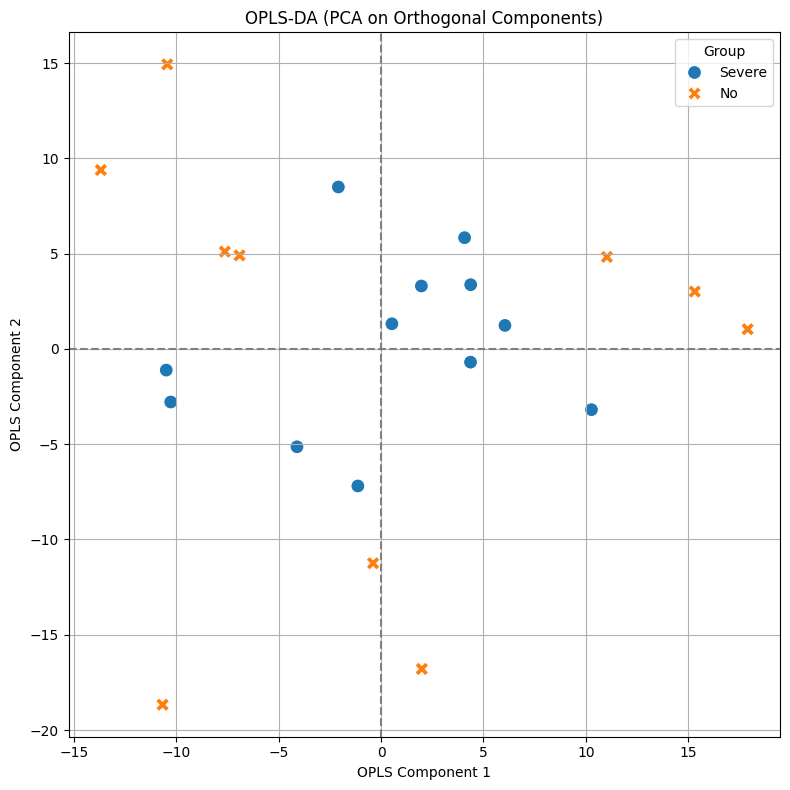

In [6]:
class OPLS_DA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=1):
        self.n_components = n_components
        
    def fit(self, X, y):
        pls = PLSRegression(n_components=self.n_components)
        pls.fit(X, y)
        T_pred = pls.x_scores_
        P_pred = pls.x_loadings_
        X_hat = T_pred @ P_pred.T
        self.X_orth = X - X_hat
        self.model = LogisticRegression(max_iter=1000)
        self.model.fit(self.X_orth, y)
        self.pls = pls
        return self

    def transform(self, X):
        T_pred = self.pls.transform(X)
        P_pred = self.pls.x_loadings_
        X_hat = T_pred @ P_pred.T
        X_orth = X - X_hat
        return X_orth

opls = OPLS_DA(n_components=1)
opls.fit(X_subset, y_subset_numeric)
X_opls = opls.transform(X_subset)
pca_opls = PCA(n_components=2)
X_vis = pca_opls.fit_transform(X_opls)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y_subset, s=100, style=y_subset)
plt.xlabel('OPLS Component 1')
plt.ylabel('OPLS Component 2')
plt.title('OPLS-DA (PCA on Orthogonal Components)')
plt.tight_layout()
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.legend(title='Group')
plt.grid(True)
plt.show()

### Random Forest (RF)


--- Cross-Validation Results ---
CV Accuracy Scores: [0.42105263 0.44444444 0.11111111]
Mean CV Accuracy: 0.3255
Std Dev CV Accuracy: 0.1519

--- Training on Full Dataset for Feature Importance ---

Top 20 Most Important Metabolites (from model trained on all data):
         Metabolite  Importance
304  Chem_100001437    0.012544
484  Chem_100001266    0.010671
201  Chem_100002009    0.010480
644  Chem_100022013    0.008738
68   Chem_100009066    0.007968
280  Chem_100015737    0.007798
144       Chem_1114    0.007696
180  Chem_100006082    0.006978
62   Chem_100008991    0.006805
517  Chem_100003415    0.006788
603  Chem_100009027    0.006613
157        Chem_111    0.006153
283  Chem_100015835    0.005856
113  Chem_100002070    0.005680
65        Chem_1528    0.005660
645  Chem_100022127    0.005584
284       Chem_1123    0.005559
268       Chem_1143    0.005549
369        Chem_561    0.005511
590  Chem_100001007    0.005358


C:\Users\ZNDX002\AppData\Local\Temp\ipykernel_10312\1104203284.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Metabolite', data=importance_df.head(top_n), palette='viridis')


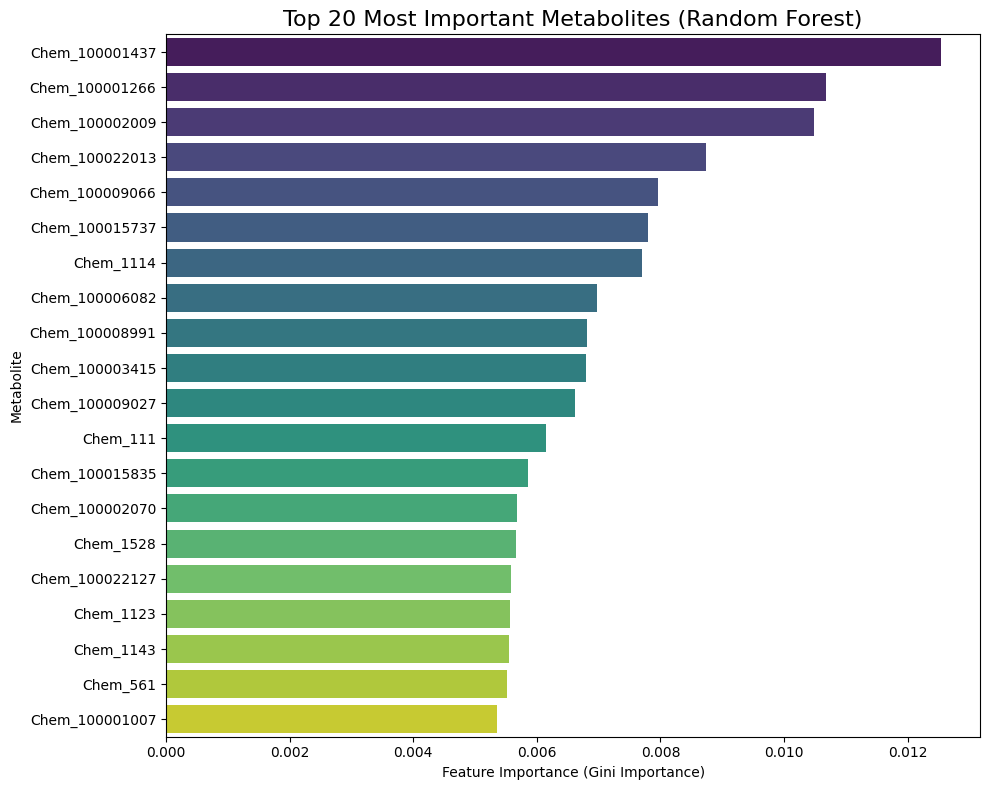

In [7]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

X_rf = X_full
y_rf = y_full
rf_model_cv = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    max_features='sqrt',
    min_samples_leaf=2, 
    class_weight='balanced' 
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model_cv, X_rf, y_rf, cv=cv, scoring='accuracy')
print("\n--- Cross-Validation Results ---")
print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

print("\n--- Training on Full Dataset for Feature Importance ---")
rf_model_final = RandomForestClassifier(
    n_estimators=200, 
    random_state=42,
    min_samples_leaf=2,
    class_weight='balanced'
)
rf_model_final.fit(X_rf, y_rf)


feature_importances = rf_model_final.feature_importances_
importance_df = pd.DataFrame({
    'Metabolite': metabolite_names,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Metabolites (from model trained on all data):")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))
top_n = 20
sns.barplot(x='Importance', y='Metabolite', data=importance_df.head(top_n), palette='viridis')
plt.title(f'Top {top_n} Most Important Metabolites (Random Forest)', fontsize=16)
plt.xlabel('Feature Importance (Gini Importance)')
plt.ylabel('Metabolite')
plt.tight_layout()
plt.show()

### Support vector machines (SVM)


--- SVM Cross-Validation Results ---
CV Accuracy Scores: [0.36842105 0.44444444 0.27777778]
Mean CV Accuracy: 0.3635
Std Dev CV Accuracy: 0.0681

--- Training on Full Dataset for Feature Importance ---

Top 20 Most Important Metabolites (from Linear SVM):
         Metabolite  Importance
519  Chem_100015785    0.016762
284       Chem_1123    0.016750
590  Chem_100001007    0.014995
119        Chem_235    0.014814
516  Chem_100020417    0.014652
56   Chem_100008952    0.014445
144       Chem_1114    0.014375
517  Chem_100003415    0.014121
272        Chem_932    0.014105
304  Chem_100001437    0.014054
211  Chem_100001359    0.013990
669       Chem_1004    0.013865
514  Chem_100004575    0.013687
359  Chem_100001126    0.013420
462  Chem_100021331    0.013371
502  Chem_100004056    0.013247
345  Chem_100001323    0.013216
74   Chem_100000827    0.013171
476  Chem_100020217    0.012922
205  Chem_100001609    0.012860


C:\Users\ZNDX002\AppData\Local\Temp\ipykernel_10312\3427339834.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Metabolite', data=svm_importance_df.head(top_n), palette='mako')


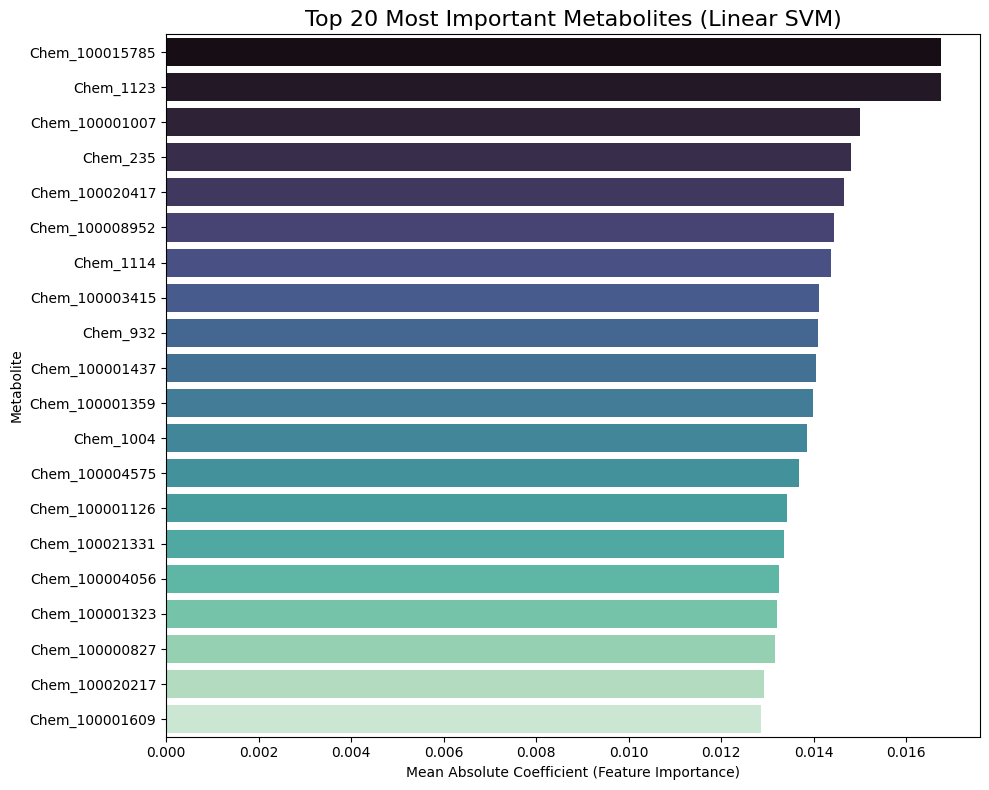

In [8]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

svm_model_cv = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, probability=True)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_svm = cross_val_score(svm_model_cv, X_full, y_full, cv=cv, scoring='accuracy')

print("\n--- SVM Cross-Validation Results ---")
print(f"CV Accuracy Scores: {cv_scores_svm}")
print(f"Mean CV Accuracy: {np.mean(cv_scores_svm):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores_svm):.4f}")


print("\n--- Training on Full Dataset for Feature Importance ---")
svm_model_final = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42)
svm_model_final.fit(X_full, y_full)


if hasattr(svm_model_final, 'coef_'):
    svm_importances = np.mean(np.abs(svm_model_final.coef_), axis=0)
    svm_importance_df = pd.DataFrame({
        'Metabolite': metabolite_names,
        'Importance': svm_importances
    })

    svm_importance_df = svm_importance_df.sort_values(by='Importance', ascending=False)

    print("\nTop 20 Most Important Metabolites (from Linear SVM):")
    print(svm_importance_df.head(20))

    plt.figure(figsize=(10, 8))
    top_n = 20
    sns.barplot(x='Importance', y='Metabolite', data=svm_importance_df.head(top_n), palette='mako')
    plt.title(f'Top {top_n} Most Important Metabolites (Linear SVM)', fontsize=16)
    plt.xlabel('Mean Absolute Coefficient (Feature Importance)')
    plt.ylabel('Metabolite')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances can only be extracted from a linear kernel SVM.")

### Hierarchical Clustering Analysis (HCA)

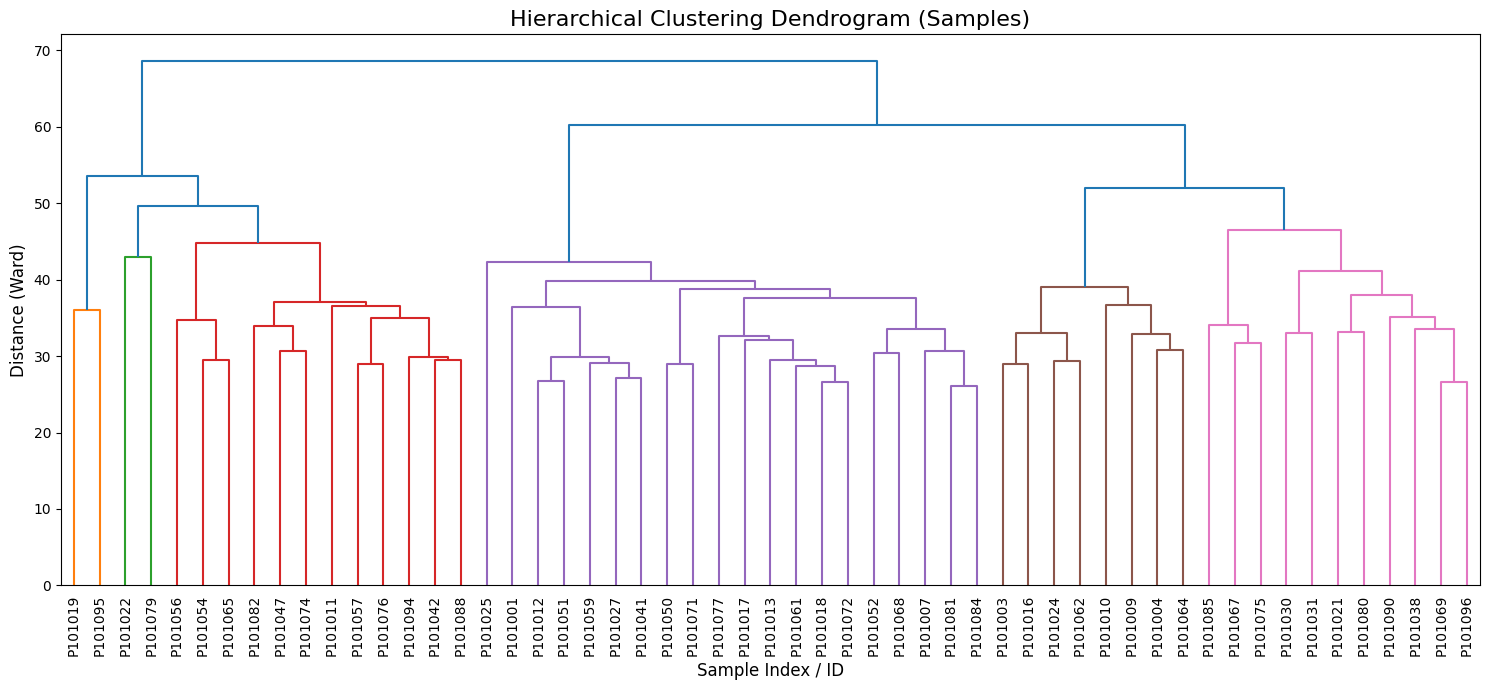

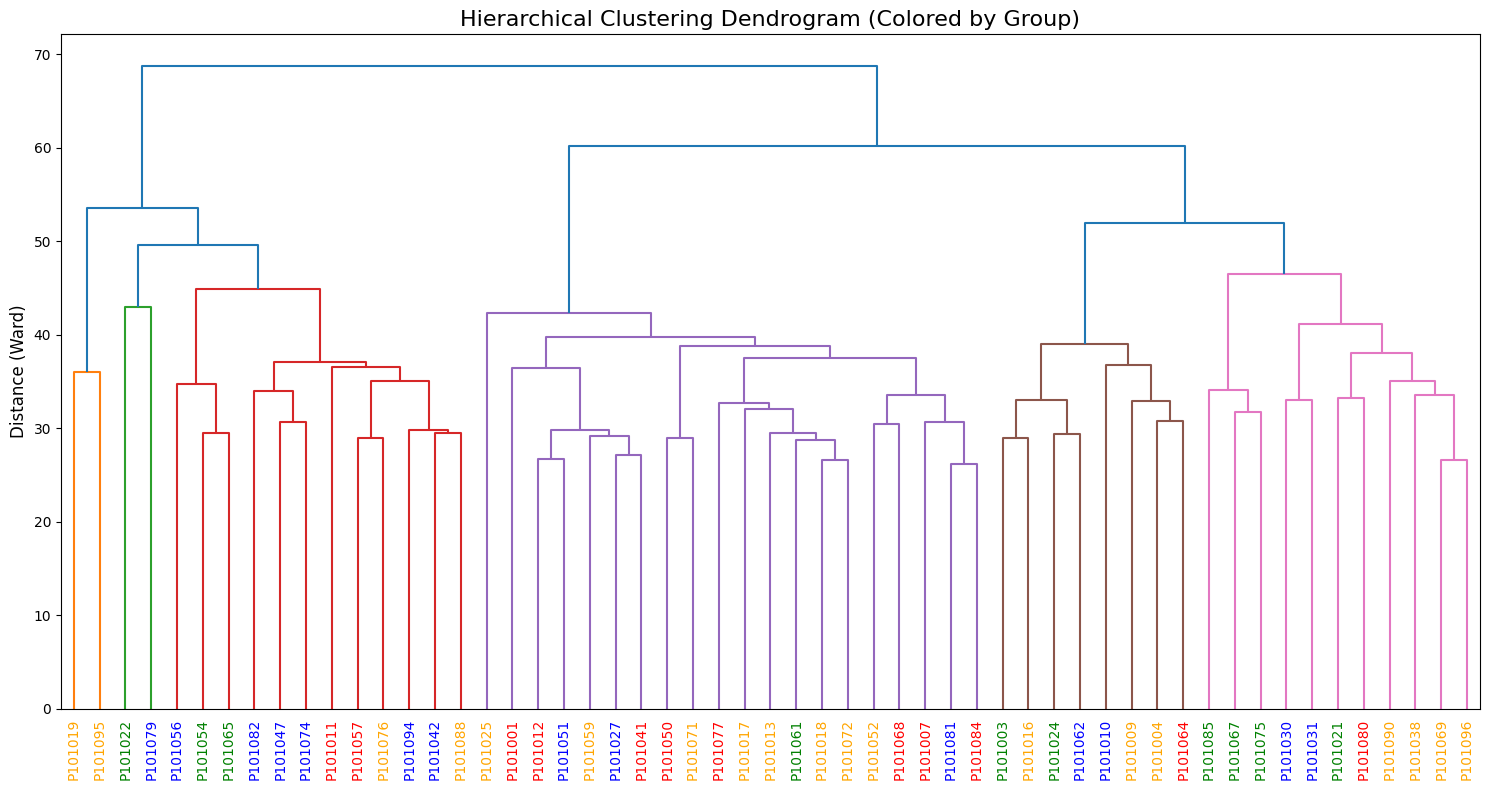


--- Generating Clustered Heatmap ---


C:\Users\ZNDX002\.conda\envs\massspecgym\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\ZNDX002\.conda\envs\massspecgym\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


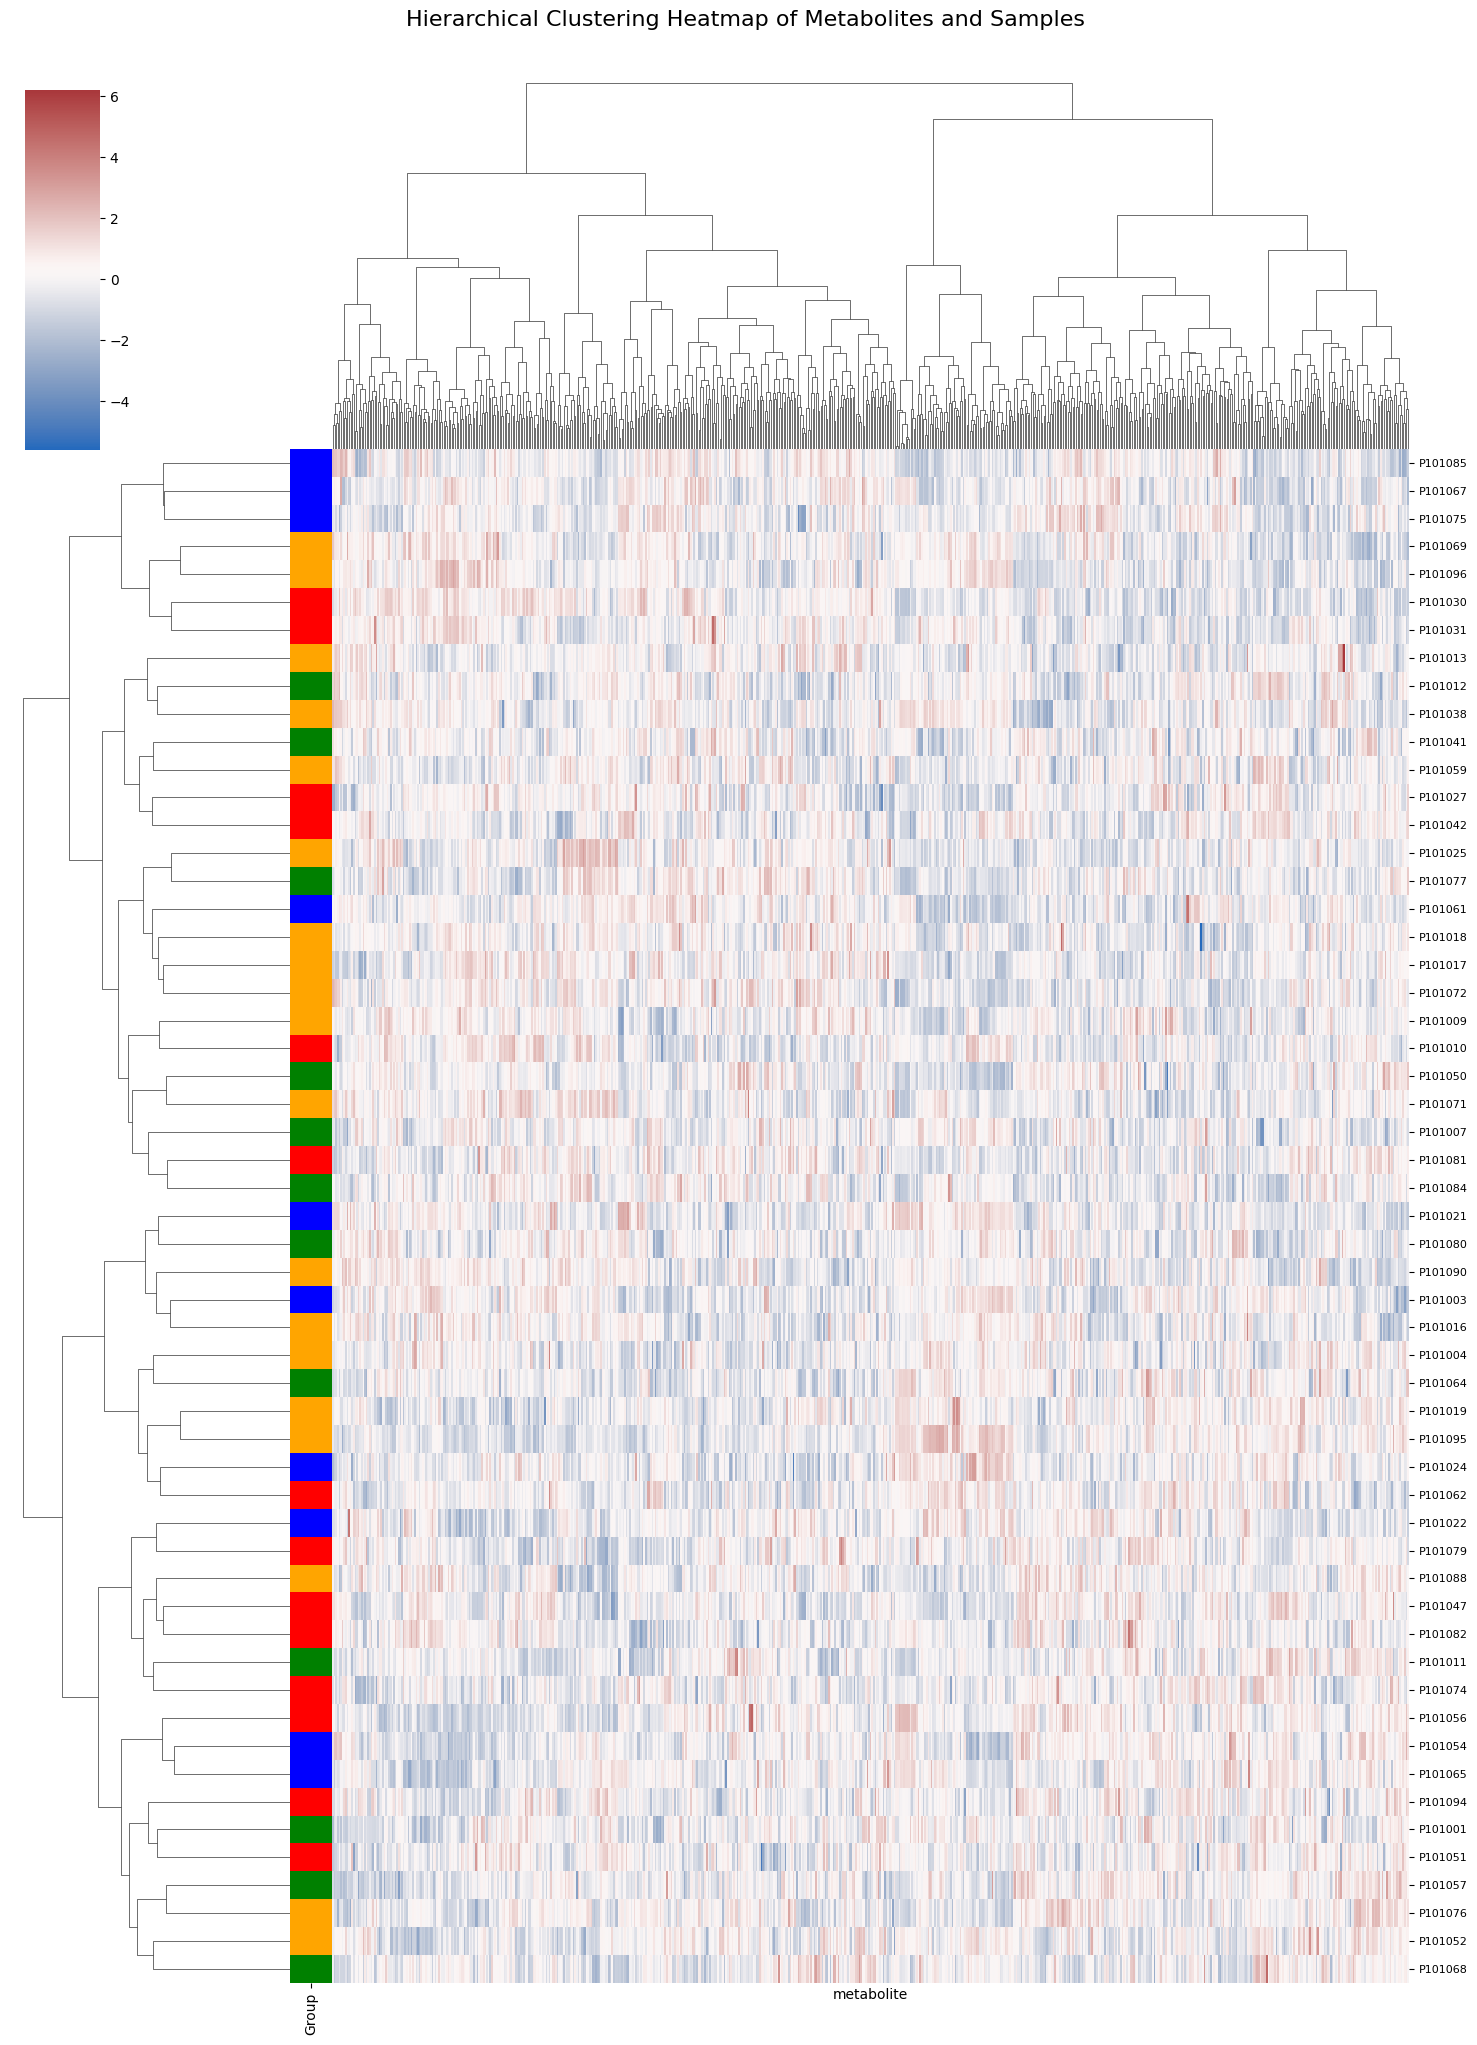

In [9]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

sample_linkage = linkage(X_full, method='ward', metric='euclidean')
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram (Samples)', fontsize=16)
plt.xlabel('Sample Index / ID', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)

dendrogram(
    sample_linkage,
    leaf_rotation=90.,  
    leaf_font_size=10.,
    labels=X_full.index.tolist()
)
plt.tight_layout()
plt.show()

group_colors = y_full.map({'No': 'green', 'Mild': 'blue', 'Moderate': 'orange', 'Severe': 'red'})
plt.figure(figsize=(15, 8))
plt.title('Hierarchical Clustering Dendrogram (Colored by Group)', fontsize=16)
plt.ylabel('Distance (Ward)', fontsize=12)
dn = dendrogram(sample_linkage, leaf_rotation=90., leaf_font_size=10., labels=X_full.index.tolist())
ax = plt.gca()
xtick_labels = ax.get_xmajorticklabels()
for label in xtick_labels:
    sample_id = label.get_text()
    label.set_color(group_colors[sample_id])
    
plt.tight_layout()
plt.show()

print("\n--- Generating Clustered Heatmap ---")
col_colors_df = pd.DataFrame({'Group': y_full})
network_pal = sns.color_palette(['green', 'blue', 'orange', 'red'], n_colors=4)
network_lut = dict(zip(y_full.unique(), network_pal))
col_colors_mapped = col_colors_df['Group'].map(network_lut)

g = sns.clustermap(
    df_metabolites.T, 
    method='ward',     
    metric='euclidean',
    z_score=0,         
    cmap='vlag',        
    col_cluster=True,  
    row_cluster=True,   
    row_colors=col_colors_mapped, 
    figsize=(15, 20),
    xticklabels=False 
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=8) 
g.fig.suptitle('Hierarchical Clustering Heatmap of Metabolites and Samples', y=1.02, fontsize=16)
plt.show()

### T-distributed stochastic neighbor embedding (t-SNE)

Number of samples: 55. Using perplexity = 5


C:\Users\ZNDX002\.conda\envs\massspecgym\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


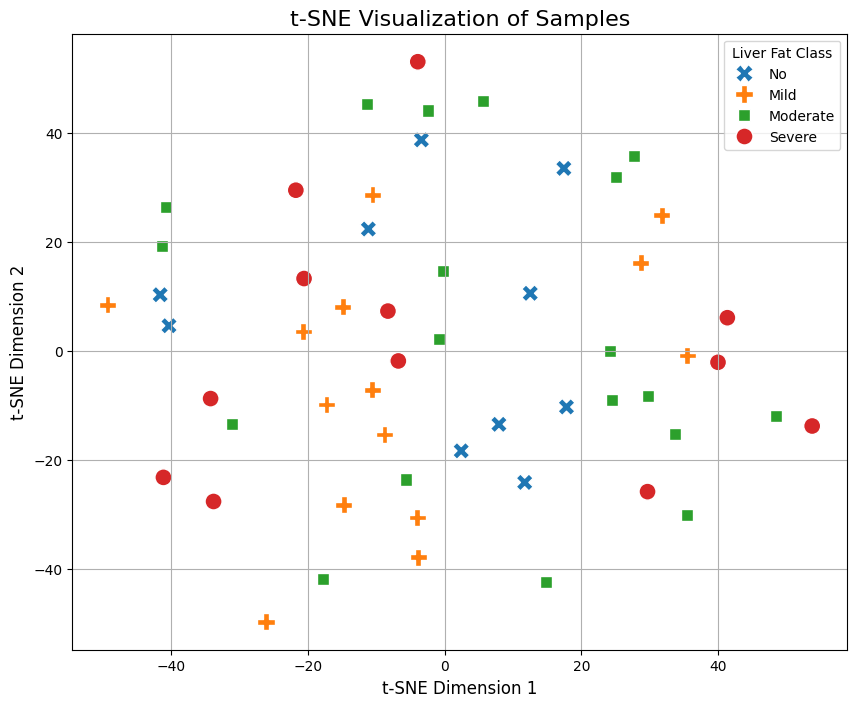

In [10]:
df_metabolites = pd.read_csv('metabolite_data.csv', index_col=0)
df_groups = pd.read_csv("sample_metadata.csv") 

X_full = df_metabolites.T
metabolite_names = X_full.columns
df_groups = df_groups.set_index('PatientID')
y_full = df_groups.reindex(X_full.index)['LiverFatClass']

n_samples = X_full.shape[0]
perplexity_value = min(5, n_samples - 1) 
print(f"Number of samples: {n_samples}. Using perplexity = {perplexity_value}")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    n_iter=1000,
    init='pca',
    learning_rate='auto', 
    random_state=42
)

X_tsne = tsne.fit_transform(X_full.astype(float))


tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_1', 'TSNE_2'])
tsne_df['Group'] = y_full.values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_1', 
    y='TSNE_2',
    hue='Group',
    style='Group',
    s=150, 
    data=tsne_df,
    hue_order=['No', 'Mild', 'Moderate', 'Severe'] 
)
plt.title('t-SNE Visualization of Samples', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Liver Fat Class')
plt.grid(True)
plt.show()

# 13.4 Over-representation analysis (ORA)

In [ ]:
import os
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
from rpy2.robjects import globalenv, NA_Integer
import numpy as np

metabo_analyst = importr('MetaboAnalystR')

In [ ]:
# Create vector consisting of compounds for enrichment analysis 
''' The first step is to create a vector containing a list of compound names. The list will then be cross-referenced (CrossReferencing) against 
the MetaboAnalyst compound libraries (HMDB, PubChem, KEGG, etc.), and any compounds without a hit will have NA.'''

compound_list_py = [
  "Acetoacetic acid", "Beta-Alanine", "Creatine", "Dimethylglycine", 
  "Fumaric acid", "Glycine", "Homocysteine", "L-Cysteine", "L-Isolucine", 
  "L-Phenylalanine", "L-Serine", "L-Threonine", "L-Tyrosine", "L-Valine", 
  "Phenylpyruvic acid", "Propionic acid", "Pyruvic acid", "Sarcosine", 
  "Arsenic", "Benzene", "Caffeic acid", "Cotinine", "Cadmium", 
  "Lead", "Thiocyanate"
]
tmp_vec_r = ro.StrVector(compound_list_py)

In [ ]:
# Create mSetObj
mSet = metabo_analyst.InitDataObjects("conc", "msetora", False)
#Set up mSetObj with the list of compounds
mSet = metabo_analyst.Setup_MapData(mSet, tmp_vec_r)
# Cross reference list of compounds against libraries (hmdb, pubchem, chebi, kegg, metlin)
mSet = metabo_analyst.CrossReferencing(mSet, "name")

In [ ]:
# Create the mapping results table
mSet = metabo_analyst.CreateMappingResultTable(mSet)
# Input the name of the compound without any matches 
mSet = metabo_analyst.PerformDetailMatch(mSet, "L-Isolucine")
# Create list of candidates to replace the compound
mSet = metabo_analyst.GetCandidateList(mSet)

In [ ]:
# Identify the name of the compound to replace
mSet = metabo_analyst.SetCandidate(mSet, "L-Isolucine", "L-Isolucine")
# Set the metabolite filter
mSet = metabo_analyst.SetMetabolomeFilter(mSet, False)
# Select metabolite set library, refer to 
mSet = metabo_analyst.SetCurrentMsetLib(mSet, "smpdb_pathway", 0)
# Calculate hypergeometric score, results table generated in your working directory
mSet = metabo_analyst.CalculateHyperScore(mSet)